# Scan Parameters

In [1]:
particle = 2
temperature = 298
scan = 216

# Import Libraries

In [1]:
import numpy as np
import pickle
import h5py
import hdf5plugin
from scipy.optimize import curve_fit
from scipy.special import erf
import sys
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import subprocess
import os


%matplotlib notebook

# Custom Functions

In [3]:
### For Opening h5 Files ###

def print_h5_item(item, indent=''):
    """
    Recursively print the contents of an h5py group or dataset.
    
    Args:
    - item: The h5py group or dataset to print.
    - indent: A string of spaces used to indent nested items for better readability.
    """
    
    if isinstance(item, h5py.Group):  # Check if item is a group
        for key, subitem in item.items():
            print(f"{indent}/{key}")  # Print group name
            print_h5_item(subitem, indent + '    ')  # Recursively print contents of the group with additional indentation
    elif isinstance(item, h5py.Dataset):  # Check if item is a dataset
        print(f"{indent}[Dataset] Shape: {item.shape}, Type: {item.dtype}")
        # To print actual data, uncomment the line below. Be cautious with large datasets.
        # print(item[:])
        
        
    # Function to save or update data in a pickle file
def append_to_pickle(file_path, new_data):
    try:
        # Try to load existing data from the file
        with open(file_path, "rb") as file:
            data = pickle.load(file)
           # print(data[0])
            if new_data[0] == data[-1][0]:
                sys.exit(f"Scan {data[-1][0]} has already been analyzed. Please try a different scan number.")
    except (FileNotFoundError, EOFError):  # If file doesn't exist or is empty
        data = []

    # Append the new data
    data.append(new_data)

    # Write the updated data back to the file
    with open(file_path, "wb") as file:
        pickle.dump(data, file)
        
        
        
def gaussian(x, A, mu, sigma, c):
    return A*np.exp(-0.5 * ((x - mu)/sigma)**2) + c

def skew_gaussian(x,A,mu,sigma,alpha,c):
    return A*np.exp(-0.5 * ((x - mu)/sigma)**2)*(1+erf(alpha*(x-mu)/np.sqrt(2))) + c

def gaussian_2d(xy, amplitude, x0, y0, sigma_x, sigma_y, theta, background):
    x, y = xy
    #x0 = float(x0)
    #y0 = float(y0)
    a = (np.cos(theta)**2)/(2*sigma_x**2) + (np.sin(theta)**2)/(2*sigma_y**2)
    b = -(np.sin(2*theta))/(4*sigma_x**2) + (np.sin(2*theta))/(4*sigma_y**2)
    c = (np.sin(theta)**2)/(2*sigma_x**2) + (np.cos(theta)**2)/(2*sigma_y**2)
    g = background + amplitude*np.exp(-(a*(x-x0)**2 + 2*b*(x-x0)*(y-y0) + c*(y-y0)**2))
    return g.ravel()

# Set Filepath to Data

In [4]:
#Change this path to where your data is located
filepath = f'/Users/eriklamb/Documents/Data/PETRA/PETRA_P10_November2023/Beamtime_11017686/CDI_Scans/Particle_{particle}/{temperature}K/NPS_01_00{scan}/'

datafile = f'e4m/NPS_01_00{scan}_master.h5'
fiofile = f'NPS_01_00{scan}.fio'

#Results path
resultspath = f'/Users/eriklamb/Documents/Data/PETRA/PETRA_P10_November2023/Beamtime_11017686/CDI_Scans/Particle_{particle}/RC_results/'

In [7]:
with h5py.File(filepath+datafile, 'r') as f:
    print_h5_item(f)

/entry
    /data
        /data_000001
            [Dataset] Shape: (501, 2167, 2070), Type: uint32
    /instrument
        /beam
            /incident_wavelength
                [Dataset] Shape: (), Type: float32
        /detector
            /beam_center_x
                [Dataset] Shape: (), Type: float32
            /beam_center_y
                [Dataset] Shape: (), Type: float32
            /bit_depth_image
                [Dataset] Shape: (), Type: int32
            /bit_depth_readout
                [Dataset] Shape: (), Type: int32
            /count_time
                [Dataset] Shape: (), Type: float32
            /countrate_correction_applied
                [Dataset] Shape: (), Type: int32
            /description
                [Dataset] Shape: (), Type: |S17
            /detectorSpecific
                /auto_summation
                    [Dataset] Shape: (), Type: int32
                /calibration_type
                    [Dataset] Shape: (), Type: |S9
                

                        [Dataset] Shape: (), Type: uint32
                    /countrate_correction_cutoff
                        [Dataset] Shape: (), Type: float32
                    /countrate_correction_lookup_table
                        [Dataset] Shape: (65535,), Type: uint32
                    /countrate_correction_table
                        [Dataset] Shape: (4000, 2), Type: float32
                    /data_origin
                        [Dataset] Shape: (2,), Type: int32
                    /data_rotation
                        [Dataset] Shape: (), Type: uint32
                    /data_size
                        [Dataset] Shape: (2,), Type: uint32
                    /enabled
                        [Dataset] Shape: (), Type: int32
                    /flatfield
                        [Dataset] Shape: (256, 1024), Type: float32
                    /frame_readout_time
                        [Dataset] Shape: (), Type: float32
                    /hv
                 

# Reading Data from h5 & fio Files

In [5]:
#From .h5 file
det = np.array(h5py.File(filepath+datafile, 'r')['entry/data/data_000001/'])

#Remove hot pixels
det[det>1000000] = 0 


#Open .fio file to extract theta values
f = open(filepath+fiofile, "r")
motors = f.readlines()[121:-1]

thetas = np.zeros(len(motors))

t = 0
for l in motors:
    thetas[t] = np.float64(l.split(' ',2)[1])
    t += 1

#Example of extracting other variables from h5 file. You may need these later.
exposure_time=np.array(h5py.File(filepath+datafile, 'r')['/entry/instrument/detector/count_time']);
frame_spacing=np.array(h5py.File(filepath+datafile, 'r')['/entry/instrument/detector/frame_time']);
wavelength = np.array(h5py.File(filepath+datafile, 'r')['entry/instrument/beam/incident_wavelength']) #Wavelength [Å]
x_pixel_size = np.array(h5py.File(filepath+datafile, 'r')['entry/instrument/detector/x_pixel_size/']) # [m]
y_pixel_size = np.array(h5py.File(filepath+datafile, 'r')['entry/instrument/detector/y_pixel_size/']) # [m]
pixelSize = x_pixel_size*10**3 # [mm]

# Reduce the Data Set

<IPython.core.display.Javascript object>


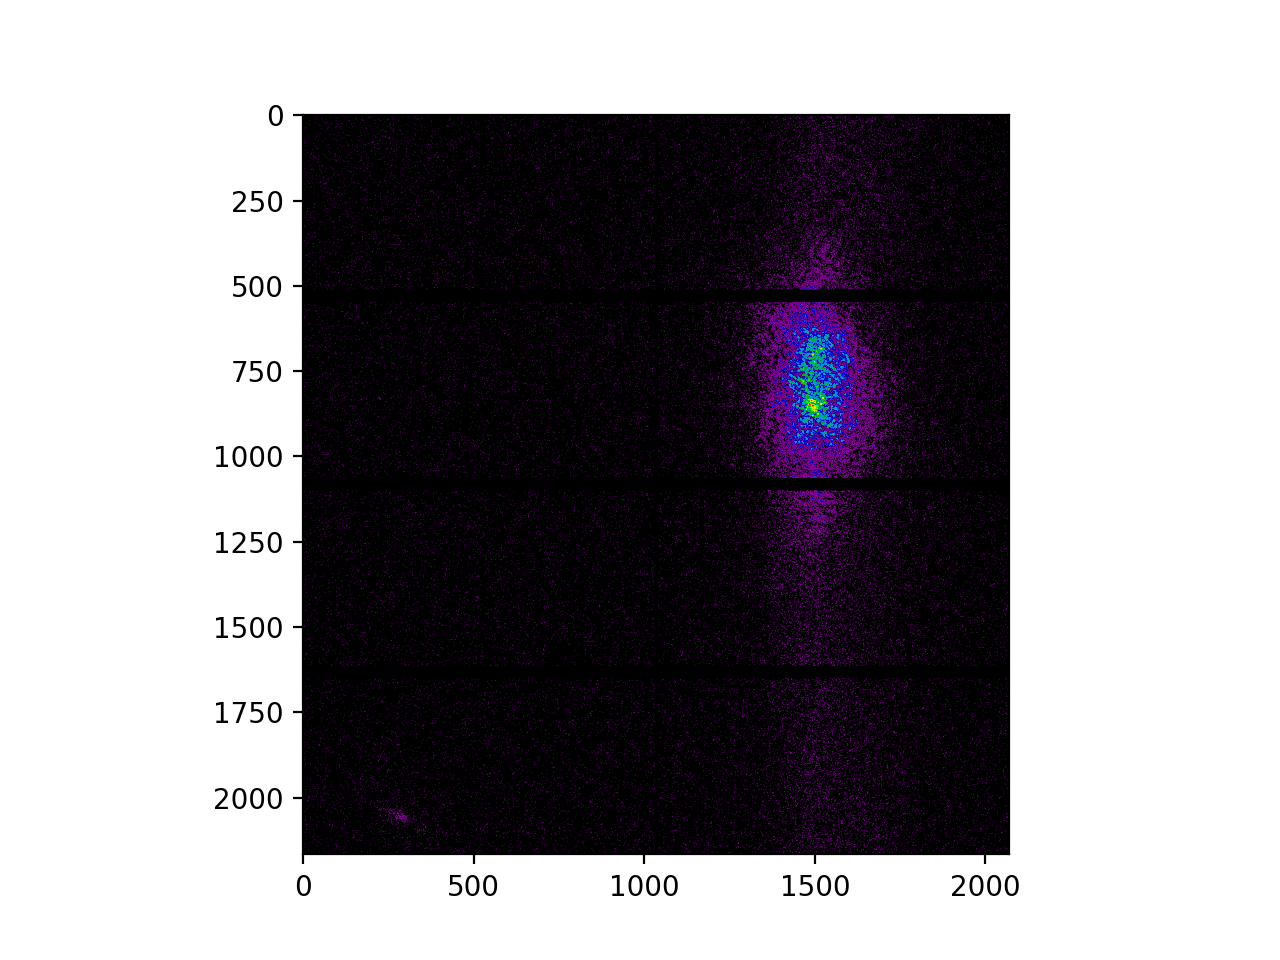

In [6]:
#Show the central 

fig, ax = plt.subplots()

central_slice = det.shape[0]//2

ax.imshow(det[central_slice,:,:]+1,cmap='nipy_spectral',norm=LogNorm(vmin=1, vmax=35))

##  Fit Peak

<IPython.core.display.Javascript object>


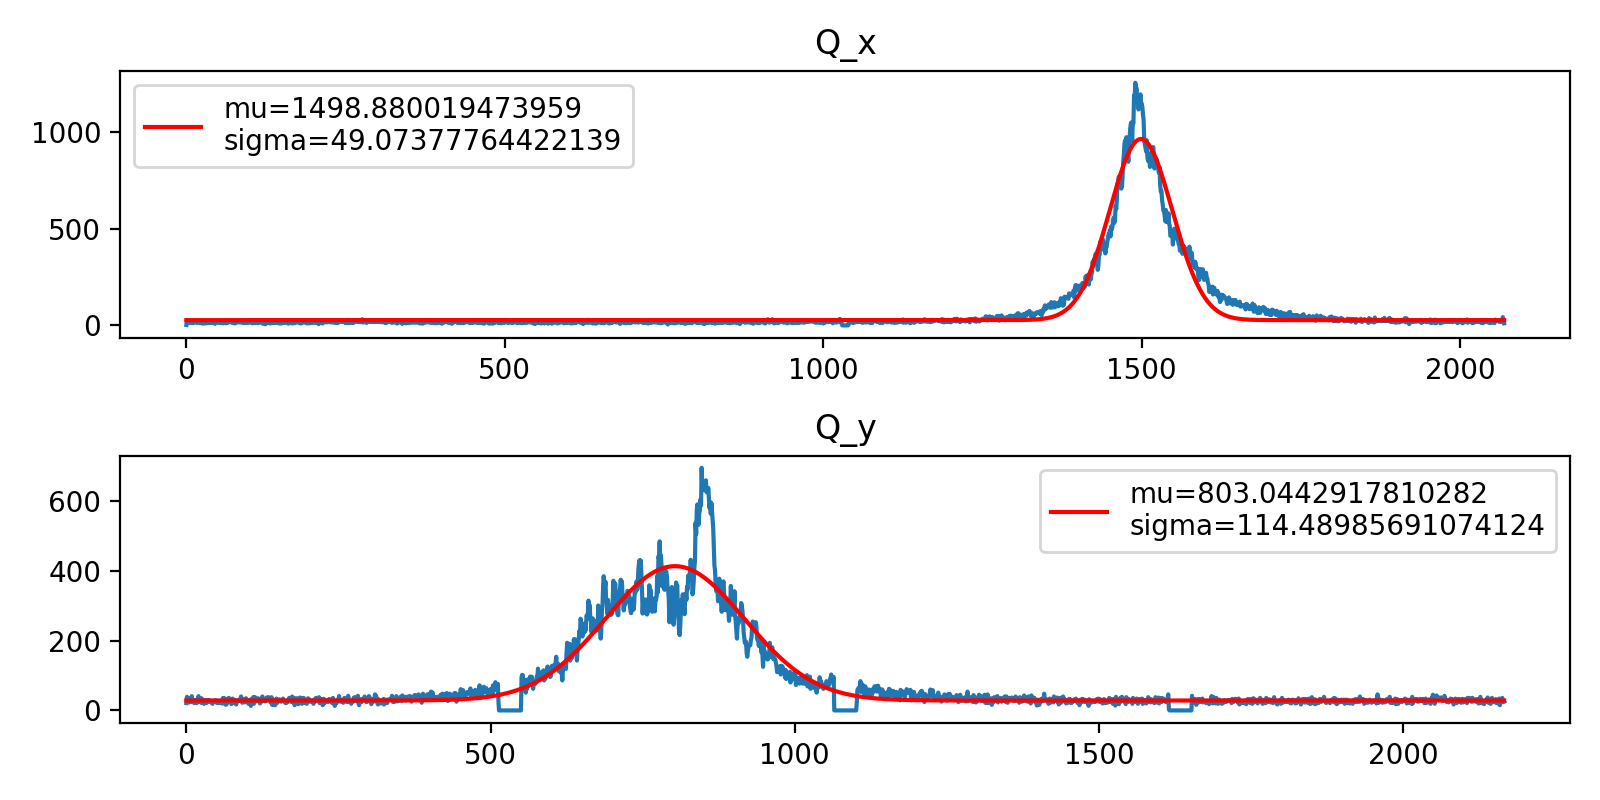

In [8]:
### Sum data along both axes for fitting ###
y1 = np.sum(det[central_slice,:,:],axis=0)
x1 = np.arange(y1.shape[0])

y2 = np.sum(det[central_slice,:,:],axis=1)
x2 = np.arange(y2.shape[0])

popt1, pcov1 = curve_fit(gaussian, x1, y1, p0=[np.max(y1), np.argmax(y1) , 1, np.min(y1[np.nonzero(y1)])])
popt2, pcov2 = curve_fit(gaussian, x2, y2, p0=[np.max(y2), np.argmax(y2) , 1, np.min(y2[np.nonzero(y2)])])

### Plotting ###
import matplotlib.pyplot as plt
%matplotlib notebook

# Create a figure and a set of subplots
fig, axs = plt.subplots(2, 1, figsize=(8, 4))  # 2 rows, 1 column

# Plot on the first axis
axs[0].plot(y1)
axs[0].plot(x1, gaussian(x1, *popt1), label='mu={}\nsigma={}'.format(popt1[1],popt1[2]), color='red')
axs[0].set_title('Q_x')
axs[0].legend()

# Plot on the second axis
axs[1].plot(y2)
axs[1].plot(x2, gaussian(x2, *popt2), label='mu={}\nsigma={}'.format(popt2[1],popt2[2]), color='red')
axs[1].set_title('Q_y')
axs[1].legend()

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

## Crop Image from Fit

<IPython.core.display.Javascript object>


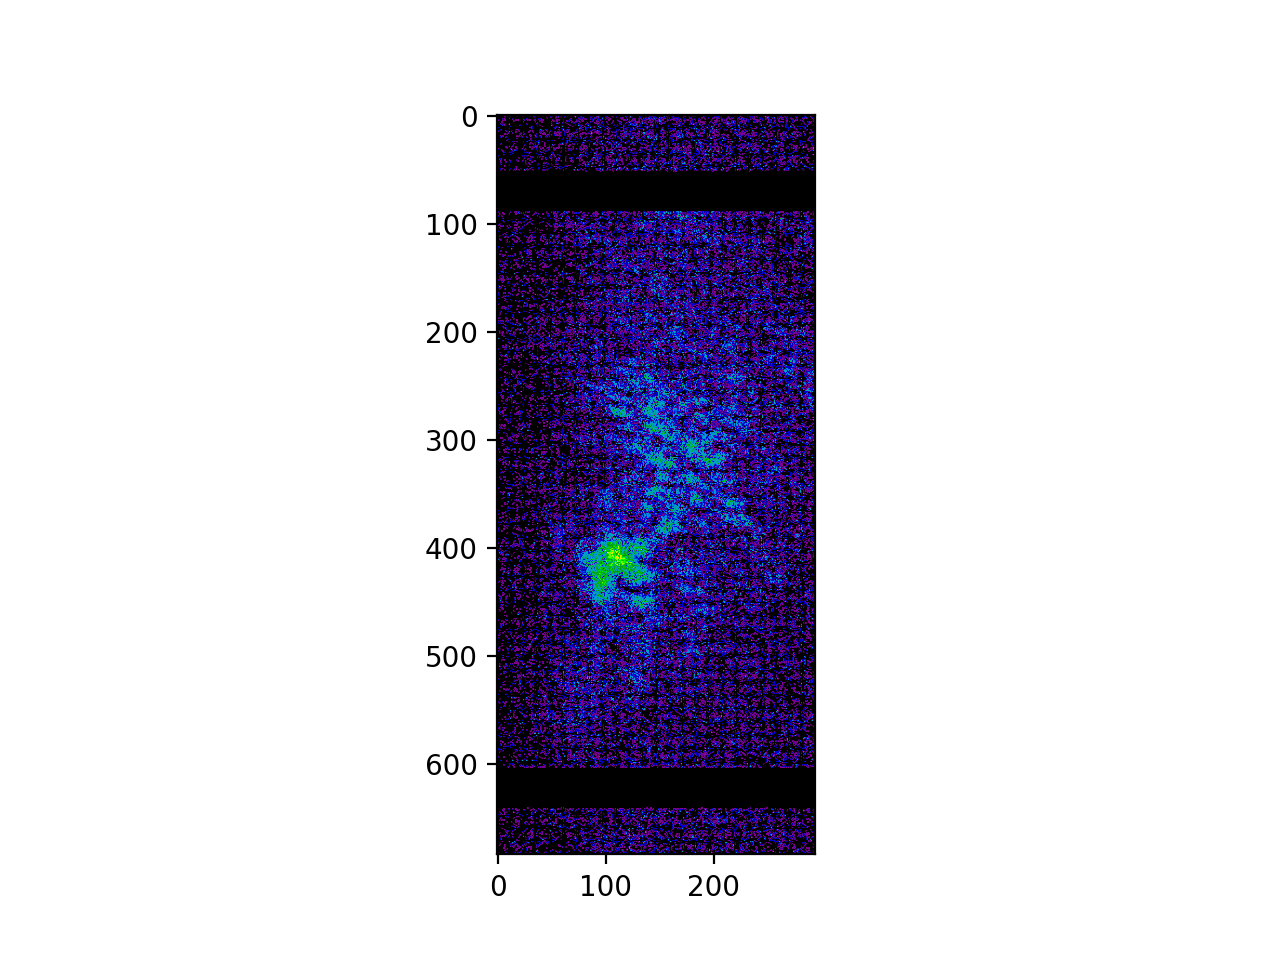

In [9]:
#Crop Size
#number of standard deviations from peak
Xv = 3 
Xh = 3


#Peak Locations
hCen = int(np.rint(popt1[1]))
vCen = int(np.rint(popt2[1]))

#Standard Deviations
hSig = int(np.rint(popt1[2]))
vSig = int(np.rint(popt2[2]))

#Set ROI
roi = [vCen-Xv*vSig,vCen+Xv*vSig,hCen-Xh*hSig,hCen+Xh*hSig] #vertical_1, vertical_2, horizontal_1, horizontal_2

#Take subset of detector
det = det[:,roi[0]:roi[1],roi[2]:roi[3]]


#Plot cropped image
fig, ax = plt.subplots()

ax.imshow(np.sum(det[0:5,:,:],axis=0)+1,cmap='nipy_spectral',norm=LogNorm(vmin=1, vmax=35))


# Rocking Curve Analysis

[More info on Full-Width at Half-Maximum](https://en.wikipedia.org/wiki/Full_width_at_half_maximum)

[More info on Mosaicity in Crystals](https://en.wikipedia.org/wiki/Mosaicity)

[Google sheet of Scans. Rocking Curves are highlighted in blue.](https://docs.google.com/spreadsheets/d/102_eWQrhPAn9BHYLmCFvJniJRwUwqi8NU6flJU8k_5Y/edit?usp=sharing)

Check the Google sheet linked above for the scan parameters

How to read scans:

e4mdscan [motor_name] [begin] [end] [num_points] [num_images] [num_darks] [exposure_time]

Example: e4mdscan samth -0.5 0.5 500 1 0 1

### Plot and Fit Rocking Curve

<IPython.core.display.Javascript object>


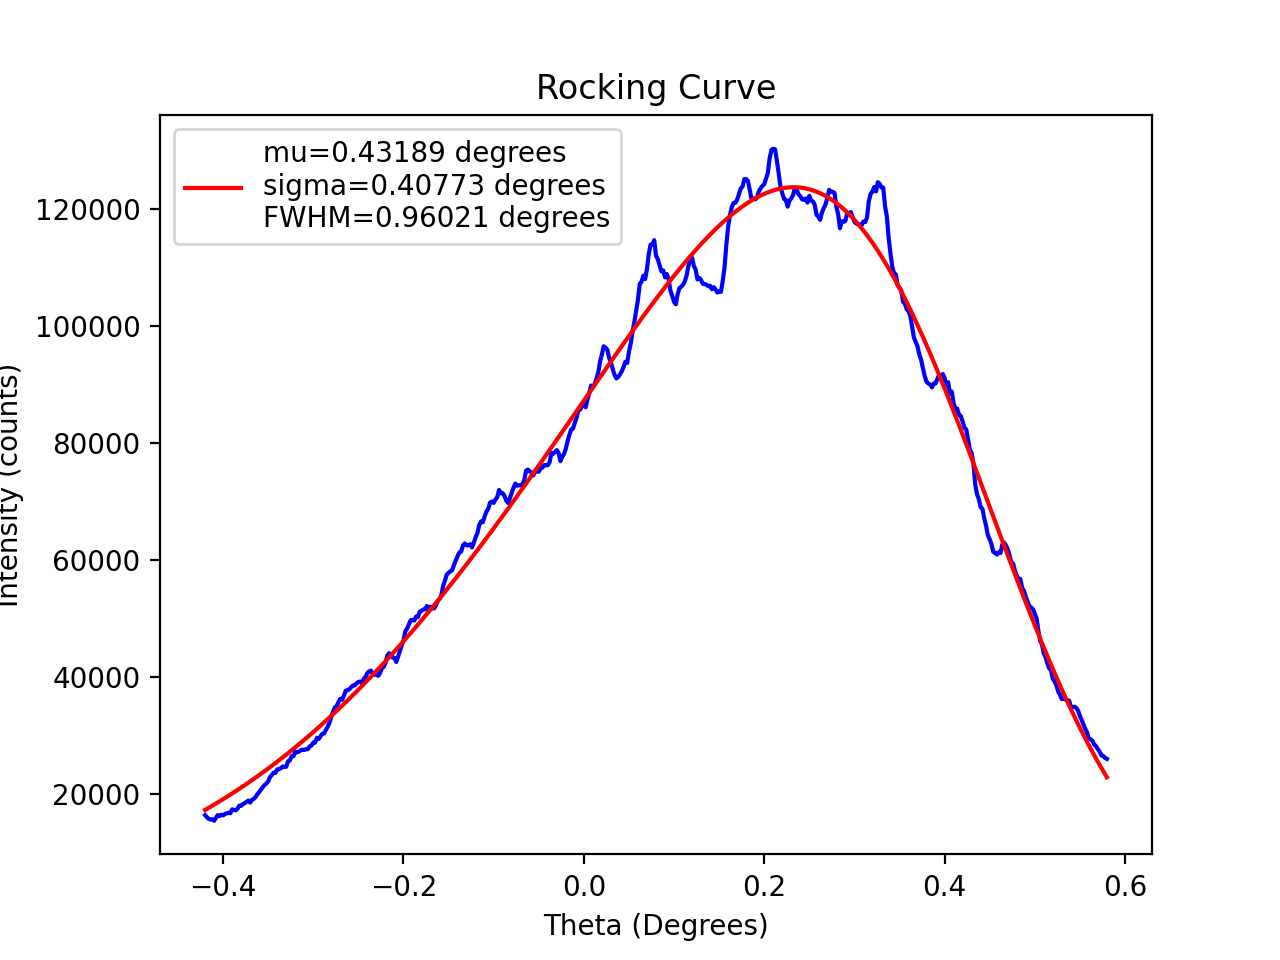

[ 7.66066599e+04  4.31890623e-01  4.07732035e-01 -6.73207171e+00
  3.67111794e-09]
[7.03689978e+02 2.60529081e-03 5.96002984e-03 9.76172514e-02
 1.39405484e+03]


In [20]:
#Create an array of theta values from the information above.
#thetas = np.linspace(begin,end,num_points+1)  #Note it's num_points+1 !!!

#Sum the intensity in the ROI
II = np.sum(det,axis=(1,2)) #II stands for integrated intensity


lower_bounds = [-np.inf,-np.inf,-np.inf, -np.inf, 0]  # c >= 0
upper_bounds = [np.inf, np.inf, np.inf,np.inf,np.inf]
#Fit 
popt, pcov = curve_fit(skew_gaussian, thetas, II, p0=[np.max(II), thetas[np.argmax(II)] , 0.2,-1, np.min(II[np.nonzero(II)])],bounds=(lower_bounds, upper_bounds))


#Plot
fig,ax = plt.subplots()

ax.plot(thetas,II,'b')
ax.plot(thetas, skew_gaussian(thetas, *popt), label=f'mu={popt[1]:.5f} degrees\nsigma={popt[2]:.5f} degrees\nFWHM={2.355*popt[2]:.5f} degrees', color='red')
ax.set_xlabel('Theta (Degrees)')
ax.set_ylabel('Intensity (counts)')
ax.set_title('Rocking Curve')
ax.legend()

print(popt)
print(np.sqrt(np.diag(pcov)))

# Save Data

In [75]:
#Compile results 
#Results are saved in the following order:
#scan, temperature, A,mu,sigma,alpha,c, A_err,mu_err,sigma_err,alpha_err,c_err 
results = np.concatenate(([scan,temperature],popt,np.sqrt(np.diag(pcov))))

#Check that path exists. Make a new one if it does not 
if not os.path.exists(resultspath):
    os.mkdir(resultspath)
    if os.path.exists(resultspath):
        print(f"Directory '{resultspath}' created!")

#Save to file
append_to_pickle(resultspath+"particle2_results.pkl", results)
